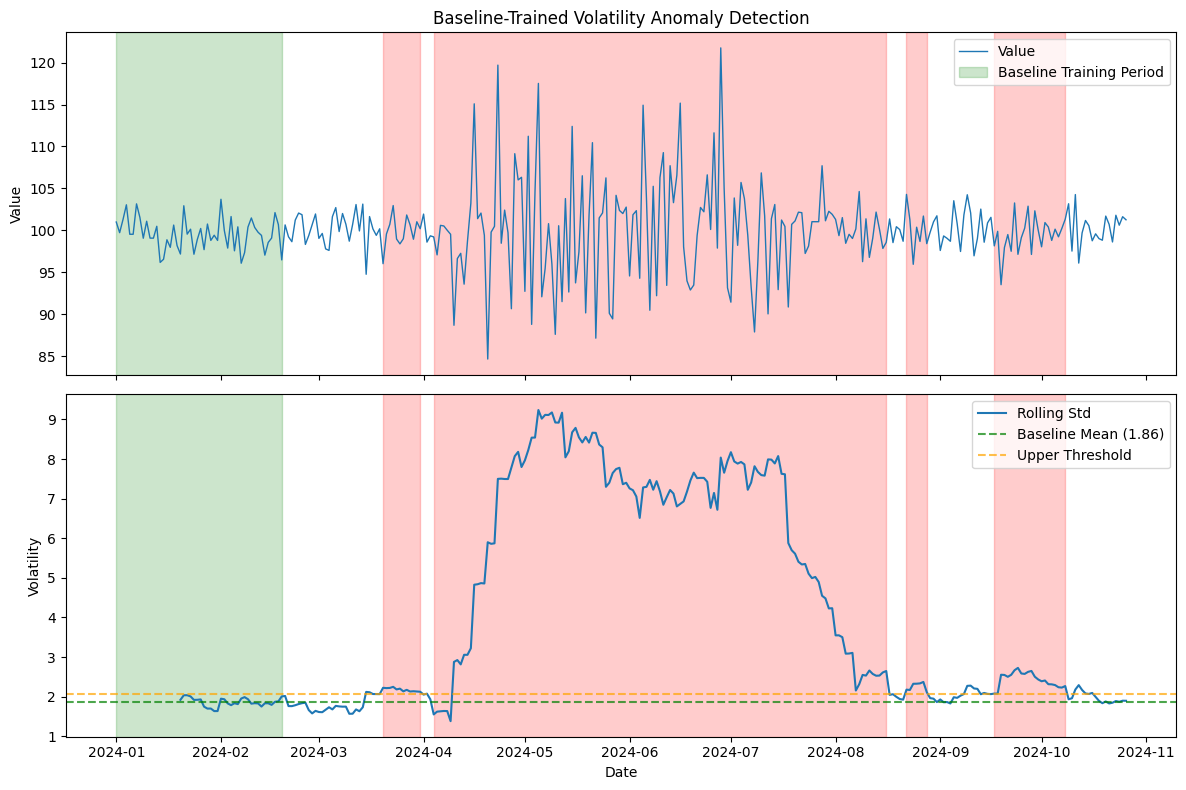

Model trained on baseline:
  Baseline mean volatility: 1.86
  Baseline std: 0.11
  Detection threshold: 2.08

Detected anomaly periods:
  2024-03-20 to 2024-03-31 (12 days, avg vol: 2.18)
  2024-04-04 to 2024-08-16 (135 days, avg vol: 6.31)
  2024-08-22 to 2024-08-28 (7 days, avg vol: 2.26)
  2024-09-17 to 2024-10-08 (22 days, avg vol: 2.43)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

class VolatilityChangeDetector:
    def __init__(self, baseline_window=50, threshold=3):
        self.baseline_window = baseline_window
        self.threshold = threshold
        self.baseline_mean = None
        self.baseline_std = None
        
    def fit(self, data):
        """Train on baseline (normal) data"""
        self.baseline_mean = np.mean(data)
        self.baseline_std = np.std(data)
        return self
    
    def detect(self, data):
        """Detect anomalies based on baseline"""
        z_scores = np.abs((data - self.baseline_mean) / self.baseline_std)
        return z_scores > self.threshold

# Generate data
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=300, freq='D')

low_vol_1 = np.random.normal(100, 2, 100)
high_vol = np.random.normal(100, 8, 100)
low_vol_2 = np.random.normal(100, 2, 100)
data = np.concatenate([low_vol_1, high_vol, low_vol_2])

df = pd.DataFrame({'value': data}, index=dates)

# Calculate rolling volatility
df['rolling_std'] = df['value'].rolling(window=20).std()

# Train detector on first 50 days (baseline period)
detector = VolatilityChangeDetector(baseline_window=50, threshold=2)
baseline_volatility = df['rolling_std'][:50].dropna()
detector.fit(baseline_volatility)

# Detect anomalies
df['anomaly'] = False
df.loc[df.index[50:], 'anomaly'] = detector.detect(df['rolling_std'][50:])

# Find anomaly periods
df['anomaly_regime'] = (df['anomaly'] != df['anomaly'].shift()).cumsum()
anomaly_periods = df[df['anomaly']].groupby('anomaly_regime')

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot
ax1.plot(df.index, df['value'], label='Value', linewidth=1)
ax1.axvspan(dates[0], dates[49], alpha=0.2, color='green', label='Baseline Training Period')

for _, period in anomaly_periods:
    if len(period) > 5:
        ax1.axvspan(period.index[0], period.index[-1], alpha=0.2, color='red')

ax1.set_ylabel('Value')
ax1.legend()
ax1.set_title('Baseline-Trained Volatility Anomaly Detection')

# Bottom plot
ax2.plot(df.index, df['rolling_std'], label='Rolling Std', linewidth=1.5)
ax2.axhline(y=detector.baseline_mean, color='green', linestyle='--', 
            label=f'Baseline Mean ({detector.baseline_mean:.2f})', alpha=0.7)
ax2.axhline(y=detector.baseline_mean + detector.threshold * detector.baseline_std, 
            color='orange', linestyle='--', label='Upper Threshold', alpha=0.7)
ax2.axvspan(dates[0], dates[49], alpha=0.2, color='green')

for _, period in anomaly_periods:
    if len(period) > 5:
        ax2.axvspan(period.index[0], period.index[-1], alpha=0.2, color='red', 
                    label='Anomaly Detected' if _ == list(anomaly_periods.groups.keys())[0] else '')

ax2.set_ylabel('Volatility')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

print("Model trained on baseline:")
print(f"  Baseline mean volatility: {detector.baseline_mean:.2f}")
print(f"  Baseline std: {detector.baseline_std:.2f}")
print(f"  Detection threshold: {detector.baseline_mean + detector.threshold * detector.baseline_std:.2f}")

print("\nDetected anomaly periods:")
for regime_id, period in anomaly_periods:
    if len(period) > 5:
        avg_vol = period['rolling_std'].mean()
        print(f"  {period.index[0].date()} to {period.index[-1].date()} "
              f"({len(period)} days, avg vol: {avg_vol:.2f})")

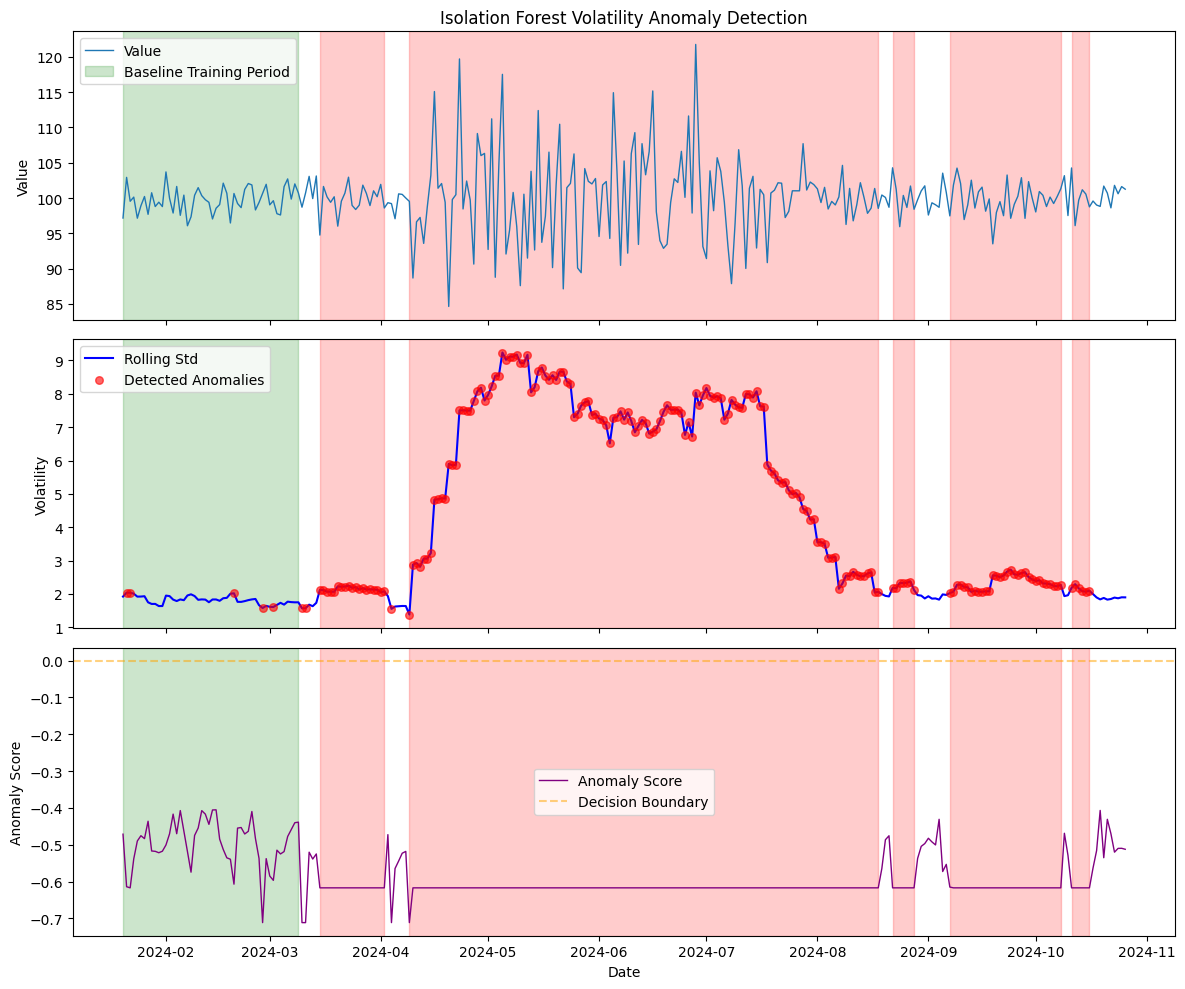

Isolation Forest Model:
  Trained on 50 baseline samples
  Contamination parameter: 0.1

Detection summary:
  Total anomalies detected: 204 / 281 (72.6%)

Anomaly periods (>5 days):
  2024-03-15 to 2024-04-02
    Duration: 19 days | Avg volatility: 2.14 | Avg score: -0.617
  2024-04-09 to 2024-08-18
    Duration: 132 days | Avg volatility: 6.42 | Avg score: -0.618
  2024-08-22 to 2024-08-28
    Duration: 7 days | Avg volatility: 2.26 | Avg score: -0.617
  2024-09-07 to 2024-10-08
    Duration: 32 days | Avg volatility: 2.34 | Avg score: -0.617
  2024-10-11 to 2024-10-16
    Duration: 6 days | Avg volatility: 2.15 | Avg score: -0.617


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generate data
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=300, freq='D')

low_vol_1 = np.random.normal(100, 2, 100)
high_vol = np.random.normal(100, 8, 100)
low_vol_2 = np.random.normal(100, 2, 100)
data = np.concatenate([low_vol_1, high_vol, low_vol_2])

df = pd.DataFrame({'value': data}, index=dates)

# Calculate rolling volatility
df['rolling_std'] = df['value'].rolling(window=20).std()
df = df.dropna()  # Remove NaN rows from rolling calculation

# Train Isolation Forest on baseline (first 50 days)
baseline_end = 50
baseline_features = df[['rolling_std']][:baseline_end]

clf = IsolationForest(
    contamination=0.1,  # Expected proportion of anomalies in baseline (usually low)
    random_state=42,
    n_estimators=100
)
clf.fit(baseline_features)

# Predict on all data (-1 = anomaly, 1 = normal)
df['if_prediction'] = clf.predict(df[['rolling_std']])
df['if_anomaly'] = df['if_prediction'] == -1

# Get anomaly scores (lower = more anomalous)
df['anomaly_score'] = clf.score_samples(df[['rolling_std']])

# Find anomaly periods
df['anomaly_regime'] = (df['if_anomaly'] != df['if_anomaly'].shift()).cumsum()
anomaly_periods = df[df['if_anomaly']].groupby('anomaly_regime')

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Top plot - original time series
ax1.plot(df.index, df['value'], label='Value', linewidth=1)
ax1.axvspan(df.index[0], df.index[baseline_end-1], alpha=0.2, color='green', label='Baseline Training Period')

for _, period in anomaly_periods:
    if len(period) > 5:
        ax1.axvspan(period.index[0], period.index[-1], alpha=0.2, color='red')

ax1.set_ylabel('Value')
ax1.legend()
ax1.set_title('Isolation Forest Volatility Anomaly Detection')

# Middle plot - rolling std
ax2.plot(df.index, df['rolling_std'], label='Rolling Std', linewidth=1.5, color='blue')
ax2.scatter(df[df['if_anomaly']].index, 
            df[df['if_anomaly']]['rolling_std'], 
            color='red', s=30, alpha=0.6, label='Detected Anomalies', zorder=5)
ax2.axvspan(df.index[0], df.index[baseline_end-1], alpha=0.2, color='green')

for _, period in anomaly_periods:
    if len(period) > 5:
        ax2.axvspan(period.index[0], period.index[-1], alpha=0.2, color='red')

ax2.set_ylabel('Volatility')
ax2.legend()

# Bottom plot - anomaly scores
ax3.plot(df.index, df['anomaly_score'], label='Anomaly Score', linewidth=1, color='purple')
ax3.axhline(y=0, color='orange', linestyle='--', alpha=0.5, label='Decision Boundary')
ax3.axvspan(df.index[0], df.index[baseline_end-1], alpha=0.2, color='green')

for _, period in anomaly_periods:
    if len(period) > 5:
        ax3.axvspan(period.index[0], period.index[-1], alpha=0.2, color='red')

ax3.set_ylabel('Anomaly Score')
ax3.set_xlabel('Date')
ax3.legend()

plt.tight_layout()
plt.show()

# Print results
print("Isolation Forest Model:")
print(f"  Trained on {len(baseline_features)} baseline samples")
print(f"  Contamination parameter: {clf.contamination}")
print(f"\nDetection summary:")
print(f"  Total anomalies detected: {df['if_anomaly'].sum()} / {len(df)} ({100*df['if_anomaly'].sum()/len(df):.1f}%)")

print("\nAnomaly periods (>5 days):")
for regime_id, period in anomaly_periods:
    if len(period) > 5:
        avg_vol = period['rolling_std'].mean()
        avg_score = period['anomaly_score'].mean()
        print(f"  {period.index[0].date()} to {period.index[-1].date()}")
        print(f"    Duration: {len(period)} days | Avg volatility: {avg_vol:.2f} | Avg score: {avg_score:.3f}")